# TD5 : Classification

Dans ce TD nous allons utiliser le jeu de données "breast cancer". La tâche est de classer chaque instance (attributs correspondants à un patient) dans une des deux classes : `"no-recurrence-events"` ou `"recurrence-events"`.
Pour cela nous allons étudier plusieurs méthodes de classification, et nous allons utiliser le package python `scikit-learn`.

## Partie 0. Un exemple pour débuter issu de données capteurs

#### A. Arbres de décision

L'ensemble de données `SENSORS.csv` consiste en 174 mesures issues de 63 capteurs de suivi de performances d'un système testé (`sensor01`-`sensor63`). Chaque test génère des valeurs pour ces 63 capteurs (`testResult`) et un état déterminé par l'équipement de test automatique (`status`). La distribution des résultats des essais est présentée ci-dessous. 

Notre objectif est de prédire le résultat enregistré par l'équipement d'essai à l'aide des données capteurs. Les résultats des tests sont les suivants : codé comme *Réussite* (correspondant à *Good*, 47% des observations) et *Échec* (toutes les autres catégories, marquées en gris). La colonne `status` est donc une version dichotomisée de la colonne `testResult` du test.

In [66]:
# import mistat pour charger des données
import mistat
# import pandas
import pandas as pd
# calculs numériques
import numpy as np
# visualisation
import matplotlib.pyplot as plt

In [67]:
# load le jeu de données sensors
sensors = mistat.load_data('SENSORS.csv')
sensors

,sensor01,sensor02,sensor03,sensor04,sensor05,sensor06,sensor07,sensor08,sensor09,sensor10,...,sensor56,sensor57,sensor58,sensor59,sensor60,sensor61,sensor62,sensor63,testResult,status
0,395.333333,735.771429,556.714286,651.980952,81.638095,68.209524,69.247619,71.542857,-545.666667,-702.228571,...,34.4,38.4,41.6,46.4,0.476096,0.350414,0.756394,2.203369,Good,Pass
1,657.800000,385.876190,833.580952,239.000000,44.247619,40.371429,50.085714,39.923810,-622.200000,-402.123810,...,1.2,35.2,3.8,7.8,0.831870,0.291837,0.859610,4.566780,Good,Pass
2,604.104762,678.171429,743.952381,496.819048,70.904762,56.314286,64.685714,52.847619,-571.895238,-550.828571,...,4.8,9.0,36.0,48.8,1.180165,0.323560,1.259943,6.345386,Good,Pass
3,348.771429,621.590476,506.476190,424.085714,55.400000,59.476190,71.342857,45.809524,-438.228571,-650.409524,...,31.2,10.4,8.0,2.2,0.709678,0.245978,0.828644,4.290314,Good,Pass
4,333.009524,624.771429,540.485714,637.047619,67.666667,64.495238,69.923810,68.714286,-470.990476,-585.228571,...,36.0,8.8,4.8,48.0,1.245587,0.429538,1.452537,8.590426,Good,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,977.457143,1110.123810,964.552381,1239.352381,43.552381,65.952381,44.819048,41.695238,-592.542857,-895.876190,...,0.2,0.4,4.0,9.8,2.619475,0.691400,2.427915,17.229805,Velocity Type II,Fail
170,1147.485714,809.523810,1086.190476,944.714286,53.133333,50.028571,49.238095,56.380952,-872.514286,-576.476190,...,0.4,44.0,4.0,0.2,2.176989,0.602622,2.172566,13.845439,Velocity Type II,Fail
171,921.390476,724.495238,892.857143,800.600000,54.857143,43.561905,58.409524,55.380952,-460.609524,-493.504762,...,4.0,6.8,3.8,36.8,1.575980,0.442073,1.475009,8.881706,Velocity Type II,Fail
172,1215.057143,888.828571,1215.352381,988.352381,56.171429,50.571429,51.752381,50.533333,-872.942857,-537.171429,...,1.2,9.8,0.4,0.2,2.473920,0.644704,2.394347,15.002947,Velocity Type II,Fail


In [68]:
# résumé du dataframe
sensors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 65 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sensor01    174 non-null    float64
 1   sensor02    174 non-null    float64
 2   sensor03    174 non-null    float64
 3   sensor04    174 non-null    float64
 4   sensor05    174 non-null    float64
 5   sensor06    174 non-null    float64
 6   sensor07    174 non-null    float64
 7   sensor08    174 non-null    float64
 8   sensor09    174 non-null    float64
 9   sensor10    174 non-null    float64
 10  sensor11    174 non-null    float64
 11  sensor12    174 non-null    float64
 12  sensor13    174 non-null    float64
 13  sensor14    174 non-null    float64
 14  sensor15    174 non-null    float64
 15  sensor16    174 non-null    float64
 16  sensor17    174 non-null    float64
 17  sensor18    174 non-null    float64
 18  sensor19    174 non-null    float64
 19  sensor20    174 non-null    f

In [69]:
# valeurs uniques de testResult
print(f"testResult: {sensors['testResult'].unique()}")
# valeurs uniques de status
print(f"status: {sensors['status'].unique()}")

testResult: ['Good' 'Grippers' 'IMP' 'Motor' 'ITM' 'Brake' 'SOS' 'Velocity Type I'
 'Velocity Type II']
status: ['Pass' 'Fail']


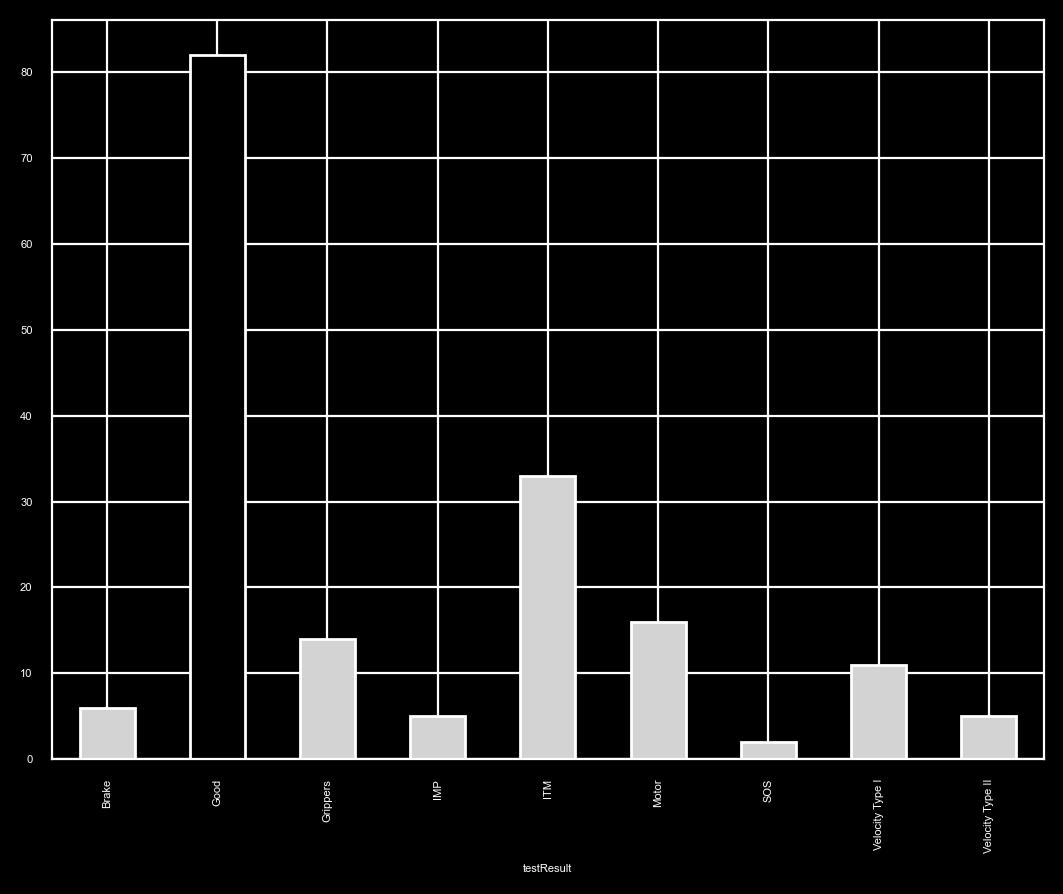

In [70]:
# distribution des résultats de test
dist = sensors['testResult'].value_counts() # calcul d'ocurrences (effectif) de chaque valeur unique (modalité)
dist = dist.sort_index()
# visualisation avec un bar plot
ax = dist.plot.bar(color='lightgrey')
ax.patches[dist.index.get_loc('Good')].set_facecolor('black') # modifier la couleur de la bar associée à la valeur "Good"
plt.show()

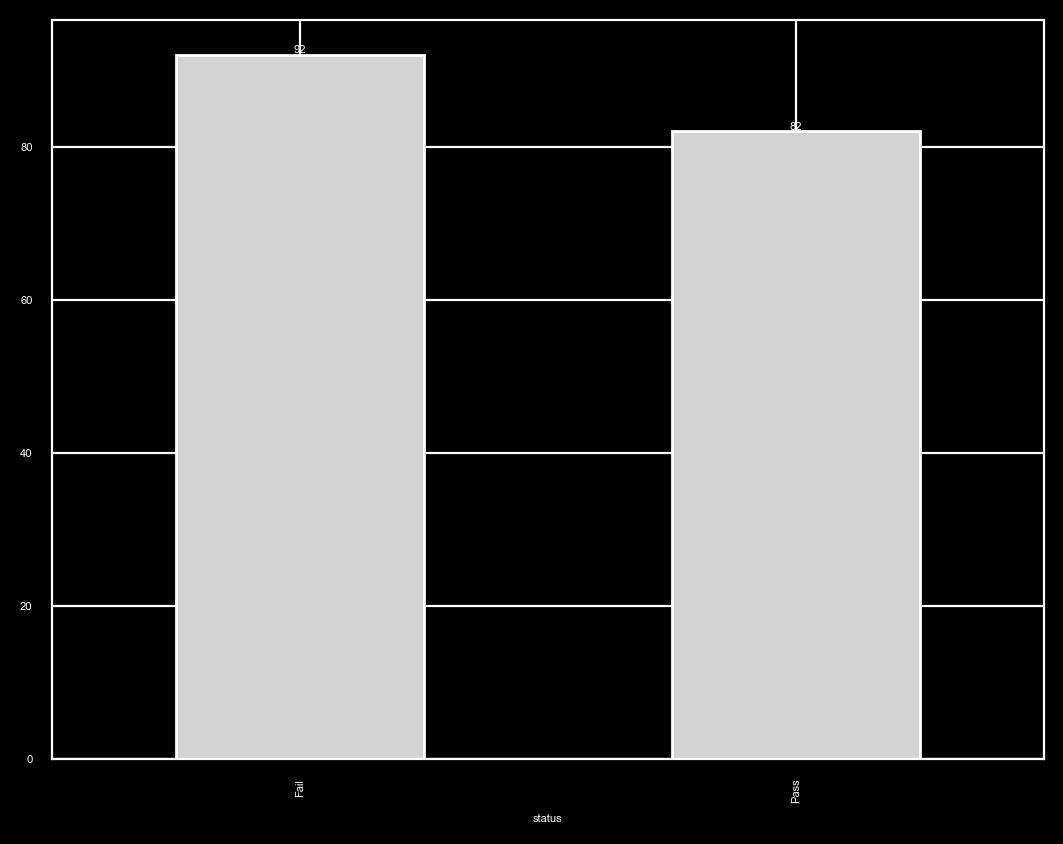

In [71]:
# distribution de statut
dist_status = sensors['status'].value_counts() # calcul d'ocurrences (effectif) de chaque valeur unique (modalité)
dist_status = dist_status.sort_index()
# visualisation avec un bar plot
ax = dist_status.plot.bar(color='lightgrey')
# ajouter des valeurs en-dessus de chaque bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.show()

L'objectif ici est de prédire le résultat enregistré par l'équipement d'essai en utilisant les données capteurs **SENSORS**. Ici nous créons un modèle de classification binaire (classes: `Fail` et `Pass`, contenus dans la colonne `status`), appelé **arbre de décision**, à l'aide des 67 capteurs. Pour cela nous allons nous servir de [`sklearn.tree.DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

In [72]:
# import des librairies
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

In [73]:
# préparation de données
predictors = [c for c in sensors.columns if c.startswith('sensor')] # liste des colonnes contenants les variables explicatives (features)
outcome = 'status' # colonne-cible
classes = ['Fail', 'Pass'] # valeurs de classes
X = sensors[predictors] # récupération de features
Y = sensors[outcome] # recupération des cibles

Le processus général appliqué est le suivant :
- création d'un modèle
- entraînement du modèle sur le jeu de données d'entraînement (`fit`)
- validation du modèle sur le jeu de données de test et son évaluation (`predict`)

Au début, nous allons appliquer le modèle sur tout le jeu de données sans passer par le découpage en train et test.

In [74]:
# entrainement du modele
clf = DecisionTreeClassifier(ccp_alpha=0.012, random_state=0) # création de modèle
clf.fit(X, Y) # entrainement

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Nous allons visualiser l'arbre avec [`sklearn.tree.plot_tree`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html).

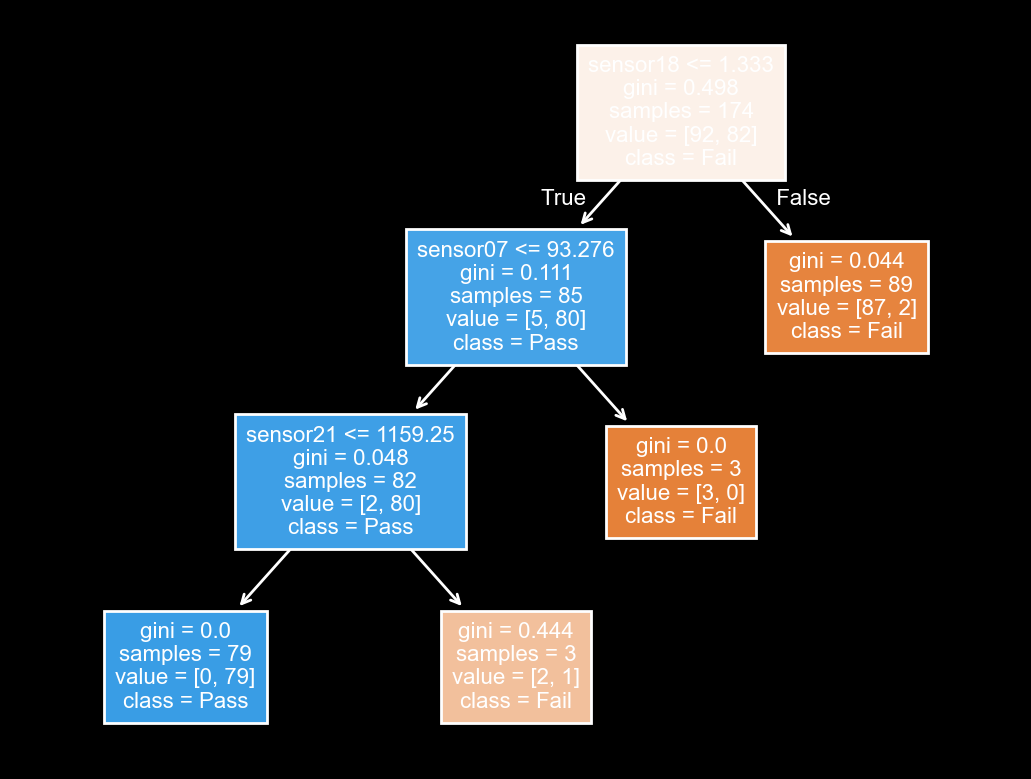

In [75]:
# visualisation de l'arbre
plot_tree(clf, feature_names=list(X.columns), class_names=classes, filled=True, impurity=True, fontsize=8)
plt.show()

In [76]:
sensors[sensors['sensor18'] > 1.333]['status'].value_counts()

status
Fail    87
Pass     2
Name: count, dtype: int64

**Interprétation de l'arbre de décision**: Il y a 92 observations de la classe *Fail* (*Échec*) et 82 de la classe *Pass* (*Réussite*). La première séparation est sur le capteur 18 avec un *point de rupture* de 1.33. Nous observons que 87 des 89 observations dont le capteur 18 à mesuré une valeur $> 1.33$ sont classées comme *Échec* (*Fail*). La plupart des observations pour lesquelles le capteur 18 a mesuré une valeur $\le 1.33$ sont classées comme *Réussites* (*Pass*) (80 sur 85). En séparant ce sous-ensemble en focntion des mesures du capteur 7 par rapport au point de rupture $93.276$, nous trouvons trois *Échecs* (les trois valeurs pour lesquelles le capteur 7 mesure une valeur $> 93.276$). Les 82 observations restantes sont séparées une troisième fois par rapport au capetur 21 et la valeur de rupture 1159.25, donnant un sous ensemble de 79 observations *Réussites* (les 79 observations pour lesquelles le capteur 21 mesure une valeur $\le 1159.25$), et un second sous-ensemble avec deux *Échecs* et un *Réussite*. 

Comme nous contrôlons la complexité de l'arbre en utilisant l'argument `ccp_alpha`, il n'y a pas de séparation supplémentaire trouvée.

L'**évaluation de la performance** d'un arbre de décision repose sur l'évaluation de sa capacité prédictive. Les observations de chaque feuille sont classées, en tant que groupe, par rapport à la probabilité de la feuille et une valeur de seuil. Le défaut limite est généralement de 50% ce qui implique que tous les types d'erreurs de classification ont le même coût. Le noeud terminal qui est atteint par le chemin à travers l'arbre de décision qui va toujours à gauche classifie tous les échantillons comme *Réussites*.
Dans tous les autres noeuds terminaux, la majorité des échantillons sont classés comme *Échec* (87 sur 89, 3 sur 3 et 2 sur 3). Le rapport des classifiés sur le total est utilisé dans scikit-learn pour déterminer une prédiciton probable pour l'échantillon.

Si, par exemple, un échantillon se retrouve dans le noeud où deux échantillons d'apprentissage sur trois sont *Échecs*, alors predict_proba renverra une probabilité de 0.66 pour *Échec* et de 0.33 pour *Réussite*.

Sur la base de ces probabilités une classification des observations dans les feuilles peut être conduite en utilisant les valeurs enregistrées et les valeurs prédites. Dans le cas de données *Échec-Réussite* de données capteurs, avec 4 fente, cela génère une matrice de confusion 2x2 affichée ci-dessous. 

Afin de construire une matrice de confusion, nous allons nous servir de [`sklearn.metrics.confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) et pour sa visualisation [`sklearn.metrics.ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html).

<div style="text-align: center;">
    <img src="img/model-eval.png" width="300" height="100">
    <p><em>True Positive (TP), True Vegative (TN), False Positive (FP), False Negative (FN)</em></p>
</div>

Precision et Recall:
$$precision = TP / (TP + FP)$$
$$recall = TP / (TP + FN)$$

<div style="text-align: center;">
    <img src="img/precision-recall.png" width="200" height="400">
    <p><em>Precision and Recall</em> </p>
</div>

$F1$-score:
$$𝐹1(𝑓)= 2×(𝑝𝑟𝑒𝑐𝑖𝑠𝑖𝑜𝑛(𝑓)\times 𝑟ecall(𝑓))/(𝑝𝑟𝑒𝑐𝑖𝑠𝑜𝑛(𝑓)+ 𝑟ecall(𝑓) )=2𝑇𝑃/(2𝑇𝑃+𝐹𝑃+𝐹𝑁)$$

In [77]:
# probabilités d'une mauvaise classsification
print('Probabilités des points mal classés')
X_pred = clf.predict(X) # prédictions faites pour les valeurs dans X
X_class_error = X.loc[X_pred != Y,:] # sous-ensemble du dataframe pour lequel les valeurs prédites ne correspondent pas aux vraie valeurs
print(X_class_error)
# probabilité de prédiction de chaque classe 
print(clf.predict_proba(X_class_error))

Probabilités des points mal classés
      sensor01    sensor02    sensor03    sensor04   sensor05   sensor06  \
45  252.238095  694.609524  370.733333  584.771429  58.238095  63.657143   
47  371.580952  456.533333  522.685714  388.971429  50.523810  44.114286   
65  360.047619  710.419048  479.352381  523.838095  37.457143  45.761905   

     sensor07   sensor08    sensor09    sensor10  ...  sensor54  sensor55  \
45  59.714286  83.104762 -441.761905 -591.390476  ...  1.907968  1.598710   
47  59.295238  63.076190 -529.419048 -458.466667  ...  2.414964  2.281921   
65  55.923810  56.219048 -337.952381 -617.580952  ...  2.535963  2.414240   

    sensor56  sensor57  sensor58  sensor59  sensor60  sensor61  sensor62  \
45      41.6       2.2      42.0       2.0  0.615531  0.364885  0.659687   
47      20.8      41.6      36.0      20.0  1.058222  0.416476  1.101594   
65       6.2      28.0      36.0      49.6  1.476755  0.427878  1.504203   

    sensor63  
45  3.087140  
47  5.033769  


In [78]:
# matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Matrice de confusion
[[92  0]
 [ 3 79]]


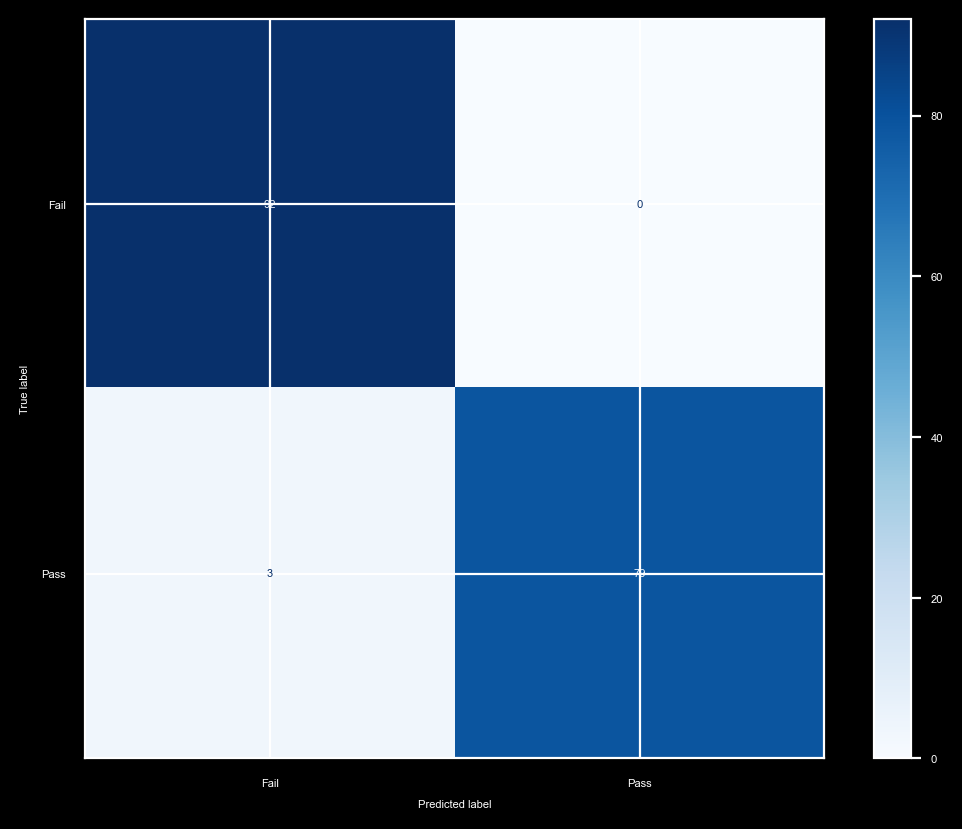

In [79]:
# actuelles en ligne / prédites en colonnes
print('Matrice de confusion')
cm = confusion_matrix(Y, clf.predict(X))
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

Seules trois observations sont mal classées. Elles correspondent aux observations qui ont été une *Réussite* dans l'équipement d'essai et ont été classées comme *Échec* par l'arbre de décision. La limite par défaut pour l'attribution de la prédiction est de 50%. Si l'on baisse la probabilité de réussita à 30%, on peut réduire le nombre de faux positifs de 1, et cependant augmenter de 2 le nombre de faux négatifs en même temps.
Cela pourrait améliorer le nombre de produits foncionnels que nous écartons à tord. Cependant, il serait également possible d'augmenter le risque d'envoi de produits défectueux.

#### B. Classification $k$-NN

L'idée se cachant derrière la méthode **$k$-nearest neighbours** est simple. Pour chaque enregistrement devant être classifié ou prédit :
- rechercher $k$ enregistrements qui ont des caractéristiques similaires ; puis
- pour la *classification* : déterminer quelle est la classe majoriatire parmi ces enregistrements similaires et affecter cette classe au nouvel enregistrement ; ou
- pour la *prédiction* : déterminer la moyenne parmi ces enregistrements similaires et prédire cette moyenne pour le nouvel enregistrement.

<div style="text-align: center;">
    <img src="img/knn-iris-diagram.png" width="400" height="600">
    <p><em>Multi-layer perceptron</em> </p>
</div>

Voir la partie 7 ci-dessous pour un exemple.

#### C. Réseaux de neurones

Les réseaux de neurones sont utilisés pour la classification et la prédiction. Ils peuvent capturer des relations complexes entre les sorties et un ensemble de valeurs prédites, appelées *predictors*. Les réseaux "apprennent" et mettent-à-jour le modèle de manière itérative au fur et à mesure que de nouvelles données lui sont introduites. 
Un important danger des réseaux de neurones et le **surapprentissage**, ou *overfitting*. Il nécessite de grandes quantités de données et possède une bonne performance prédictive, mais il s'agit d'une "boite noire" par nature.

<div class="alert alert-block alert-info">
    Un <b>réseau de neurones</b> est un ensemble d'unités de calculs, appelées <b>neurones</b>, reliés entre eux par des connexions (pondérées). Les neurones sont organisés en <b>couches</b> (entrée, sortie, ou cachée) de sorte que chaque neurone d'une couche est exclusivement connecté aux neurones de la couche précédente et de la couche suivante :<br/>
    - l'<i>entrée</i> ne reçoit des informations que de l'environnement externe où chaque neurone correspond généralement à une <i>variable explicative</i> ;<br/>
    - la <i>sortie</i> produit les résultats finaux, qui sont envoyés par le réseau à l'extérieur du système. Chacun de ses neurones correspond à une <i>variable de réponse</i>. Il y a généralement deux variables de réponses ou plus ; et<br/>
    - les couches <i>cachées</i>, situées entre l'entrée et la sortie, sont des couches intermédiaires et ne sont pas directement en contact avec l'environement extérieur. Ces couches sont exclusivement destinées à l'analyse. Leur fonction est de prendre la relation entre les variables d'entrée et les variables de sortie et de l'adapter le plus étroitement possible aux données.
</div>


<div style="text-align: center;">
    <img src="img/mlp-diagram.png" width="400" height="600">
    <p><em>Multi-layer perceptron</em> </p>
</div>

<div style="text-align: center;">
    <img src="img/iris-mlp-diagram.png" width="400" height="600">
    <p><em>Multi-layer perceptron on Iris dataset</em> </p>
</div>


Pour illustrer l'utilisation des réseaux de neurones, nous utilisons les données ABC.csv, d'une enquête de satisfaction auprès de clients. Ce jeu de donnés est consistuté de 266 réponses à un questionnaire avec une question sur la satisfaction générale (q1) et les réponses à 125 autres questions.

In [80]:
# charger le jeu de données
abc = mistat.load_data('ABC.csv')
abc

,ID,q1,q4,q5,q6,qi6,q7,qi7,q8,qi8,...,Prob(q1==2),Prob(q1==3),Prob(q1==4),Prob(q1==5),Most Likely q1,Prob 1,Prob 2,Prob 3,Prob 4,Prob 5
0,1,1.0,1.0,1.0,2.0,3.0,3.0,3.0,2.0,3.0,...,0.018352,0.031262,0.043618,0.012180,1.0,0.540563,0.155918,0.189388,0.094568,0.019563
1,2,3.0,4.0,4.0,4.0,NaN,1.0,NaN,3.0,NaN,...,0.008555,0.886537,0.085463,0.015681,3.0,0.021444,0.106375,0.609391,0.243143,0.019647
2,3,4.0,3.0,2.0,4.0,3.0,2.0,3.0,3.0,3.0,...,0.184474,0.057923,0.565705,0.185244,4.0,0.032236,0.102200,0.322007,0.514235,0.029322
3,4,3.0,4.0,4.0,3.0,3.0,2.0,2.0,2.0,3.0,...,0.008555,0.886537,0.085463,0.015681,3.0,0.008068,0.107458,0.540079,0.322584,0.021812
4,5,5.0,4.0,4.0,5.0,3.0,5.0,3.0,4.0,3.0,...,0.002498,0.007760,0.875263,0.113380,4.0,0.009538,0.035688,0.070052,0.516593,0.368130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,262,4.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,...,0.184474,0.057923,0.565705,0.185244,4.0,0.016547,0.083417,0.300571,0.565676,0.033789
262,263,5.0,5.0,5.0,3.0,3.0,4.0,3.0,4.0,3.0,...,0.007003,0.021151,0.049932,0.918832,5.0,0.004752,0.022272,0.057697,0.337506,0.577772
263,264,3.0,4.0,4.0,4.0,3.0,2.0,3.0,5.0,3.0,...,0.002139,0.388301,0.604699,0.003920,4.0,0.016514,0.054642,0.557391,0.324366,0.047086
264,265,5.0,5.0,5.0,5.0,3.0,4.0,3.0,4.0,3.0,...,0.001751,0.005288,0.373594,0.618597,5.0,0.004253,0.011445,0.039249,0.216299,0.728755


In [81]:
# résumé du dataframe
abc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Columns: 147 entries, ID to Prob 5
dtypes: float64(139), int64(7), object(1)
memory usage: 305.6+ KB


In [82]:
# colonnes contenant les variables explicatives
all_questions = [c for c in abc.columns if c.startswith('q')]
abc[all_questions] = abc[all_questions].astype('category') # convertir en variables catégorielles

In [83]:
questions = ['q1', 'q4', 'q5', 'q6', 'q7']
q1_5 = (abc['q1'] == 5) # q1 est une question sur la satisfaction générale

In [84]:
q1_5

0      False
1      False
2      False
3      False
4       True
       ...  
261    False
262     True
263    False
264     True
265    False
Name: q1, Length: 266, dtype: bool

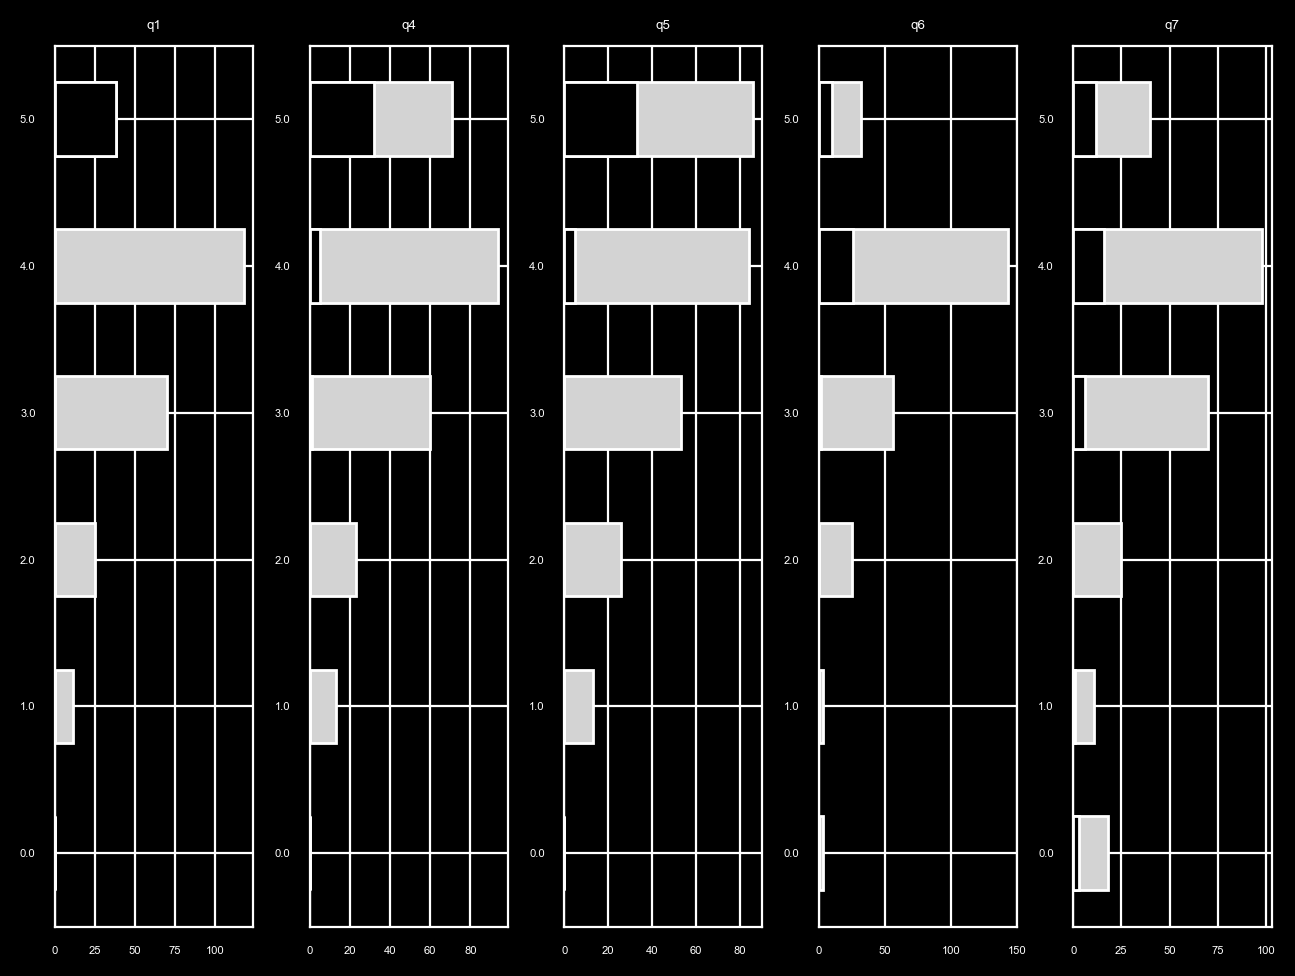

In [85]:
# visualisation par question
fig, axes = plt.subplots(ncols=len(questions))
for ax, question in zip(axes, questions):
    # extraire les réponses à la question données
    response = abc[question]
    
    # dataframe contenant la distribution de réponse à la question donnée
    # de toutes les personnnes et de personnes satisfaites, i.e. qui ont répondu 5 à la question 1
    df = pd.DataFrame([
        {satisfaction: counts for satisfaction, counts in response.value_counts().items()},
        {satisfaction: counts for satisfaction, counts in response[q1_5].value_counts().items()},
    ])
    # transposition 
    df = df.transpose()
    
    # ajout d'une ligne de 0 pour les satisfactions manquantes
    for s in range(6):
        if s not in df.index:
            df.loc[s] = [0, 0]
    
    df = df.fillna(0) # remplir les valeurs manquantes avec 0
    df = df.sort_index() # index contient les satisfaction
    df.columns = ['counts', 'counts_q1_5'] # renomme les colonnes
    
    df['counts'].plot.barh(y='index', ax=ax, color='lightgrey')
    df['counts_q1_5'].plot.barh(y='index', ax=ax, color='black')
    
    ax.set_ylim(-0.5, 5.5)
    ax.set_title(question)
    
plt.tight_layout()
plt.show()

Nous pouvons constater que la réponse 5 dans q1 correpsond à la réponse la plus donnée aux questions q4, q5, q6 et q7. Basés sur de telles réponses dans q4 à q6, nous pouvons prédire avec confiance que la réponse 5 pour q1.

In [86]:
# remplacer les valeurs manquantes avec simples stratégies comme les stats de base (mean, median, mode)
from sklearn.impute import SimpleImputer

In [87]:
predictors = list(all_questions)
predictors.remove('q1')
target = 'q1'
# q1 possède des valeurs manquantes - supprime les lignes du jeu de données
q1_missing = abc[target].isna()
X = abc.loc[~q1_missing, predictors]
Y = abc.loc[~q1_missing, target]
# remplir les valeurs manquante avec les valeurs les plus fréquentes
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
X = imp.fit_transform(X)

In [88]:
# import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

In [89]:
# normalisation des variables explicatives (pour qu'elles soient dans l'intervalle ]0,1[
X = MinMaxScaler().fit_transform(X)

Pour la classification, nous allons utiliser le modèle Multi-layer Perceptron [`sklearn.neural_network.MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

In [90]:
from sklearn.neural_network import MLPClassifier

In [91]:
# modèle multi-layer perceptron
clf = MLPClassifier(hidden_layer_sizes=(4, ), activation='logistic', solver='lbfgs', 
                    max_iter=1000, random_state=1)
clf.fit(X, Y) # apprentissage
# clf.predict(X) # prédiction

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(4,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


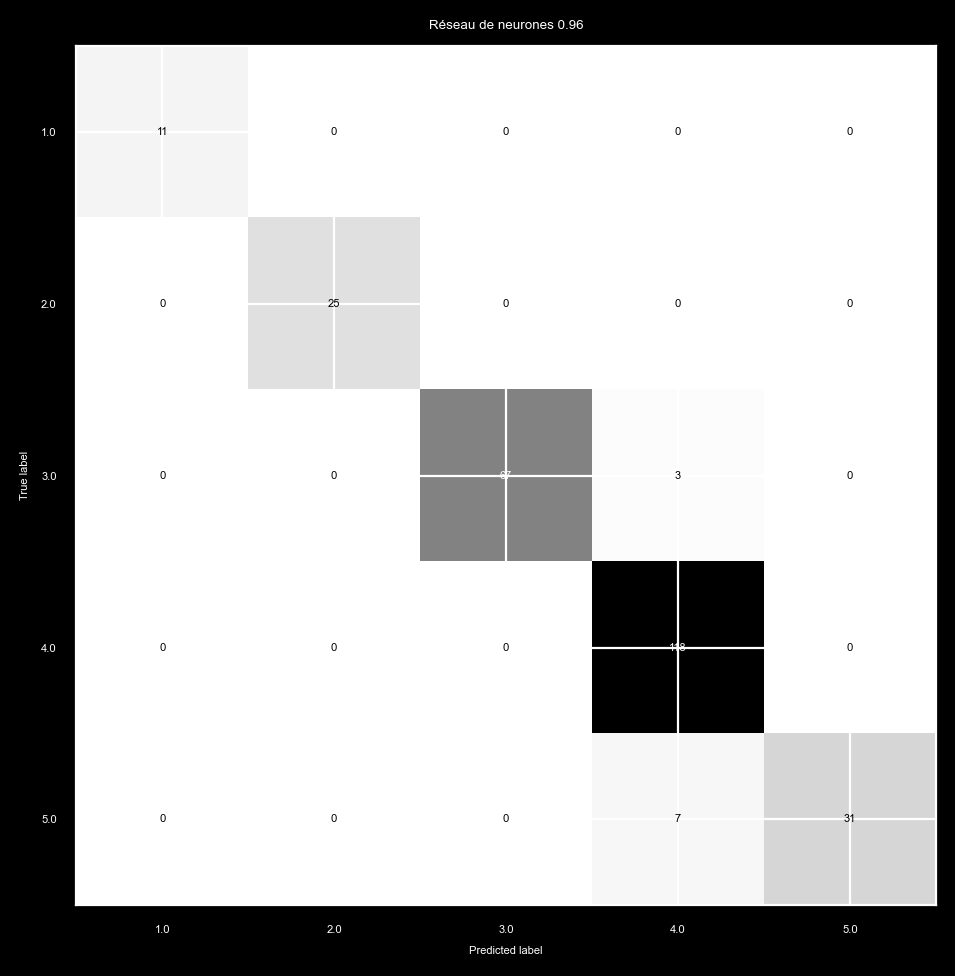

In [92]:
# visualisation de la matrice de confusion sur le jeu de données d'apprentissage
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_estimator(clf, X, Y, ax=ax, cmap=plt.cm.Greys, 
                                      colorbar=False)

ax.set_title(f'Réseau de neurones {accuracy_score(Y, clf.predict(X)):.2f}')
plt.tight_layout()

Le modèle résultat possède une précision de 96%. Cependant, il faut être prudent car cela peut provenir d'un *surapprentissage*. Cela nécessitera une surveillance du processus d'apprentissage en utilisnat les données de validation.

## Partie 1. Préparation de données

In [93]:
# chargement de donnees
bc = pd.read_csv("data/breast-cancer.csv", skipinitialspace=True)
bc

,class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breat-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no
...,...,...,...,...,...,...,...,...,...,...
281,recurrence-events,30-39,premeno,30-34,0-2,no,2,left,left_up,no
282,recurrence-events,30-39,premeno,20-24,0-2,no,3,left,left_up,yes
283,recurrence-events,60-69,ge40,20-24,0-2,no,1,right,left_up,no
284,recurrence-events,40-49,ge40,30-34,3-5,no,3,left,left_low,no


In [94]:
labels = bc.iloc[:,0]
data = bc.iloc[:,1:]

In [95]:
bc['class'].value_counts()

class
no-recurrence-events    201
recurrence-events        85
Name: count, dtype: int64

## Partie 2. Fonctionnalités catégorielles d'encodage

Pour la plupart des algorithmes de classification, les variables catégorielles doivent être encodées en format numérique. 
(Théoriquement, cela n'est pas nécessaire pour un arbre de décision. Mais dans l'implémentation de scikit-learn ce n'est pas le cas, et il faut que tous les attributs soient numériques.)

Voici une page avec des exemples pour pandas :

https://www.kaggle.com/code/paulrohan2020/tutorial-encoding-categorical-variables

qui ne mentionne pas la fonction [`factorize()`](https://pandas.pydata.org/docs/reference/api/pandas.factorize.html) qui peut être utilisée pour les variables nominales (non ordinales).

Et la documentation de scikit-learn à ce sujet :
https://scikit-learn.org/stable/modules/preprocessing.html#encoding-categorical-features

Par exemple pour l'attribut `"age"` (variable ordinale) :

In [96]:
age_order = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
data['age'] = data['age'].apply(lambda x: age_order.index(x))
print(data['age'].unique())

[1 2 4 3 5 0]


Et pour "menopause" (variable nominale) :

In [97]:
data['menopause'] = data.menopause.factorize()[0]

#### Question 1. Remplacer toutes les colonnes d'attributs catégoriels avec des versions numériques (y compris pour `"labels"`).
Pour afficher toutes les valeurs distinctes d'une colonne :

In [98]:
tumor_size = ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59']
data['tumor-size'] = data['tumor-size'].apply(lambda x: tumor_size.index(x))

In [99]:
inv_nodes_order = ['0-2', '3-5', '6-8', '9-11', '12-14', '15-17', '24-26']
data['inv-nodes'] = data['inv-nodes'].apply(lambda x: inv_nodes_order.index(x))

In [100]:
data['node-caps'] = data['node-caps'].factorize()[0]
data['breast'] = data['breast'].factorize()[0]
data['irradiat'] = data['irradiat'].factorize()[0]

In [112]:
data['breat-quad'] = data['breat-quad'].factorize()[0]
bc['class'].factorize()

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 Index(['no-recurrence-events', 'rec

In [102]:
labels = labels.factorize()[0]

#### Question 2. Nous pouvons visualiser les données avec la fonction [`scatter_matrix`](https://pandas.pydata.org/docs/reference/api/pandas.plotting.scatter_matrix.html) de pandas (voir code ci-dessous). Et faire une autre représentation avec la fonction [`parallel_coordinates`](https://pandas.pydata.org/docs/reference/api/pandas.plotting.parallel_coordinates.html). Quelle conclusion pouvez-vous en tirer ?

In [59]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

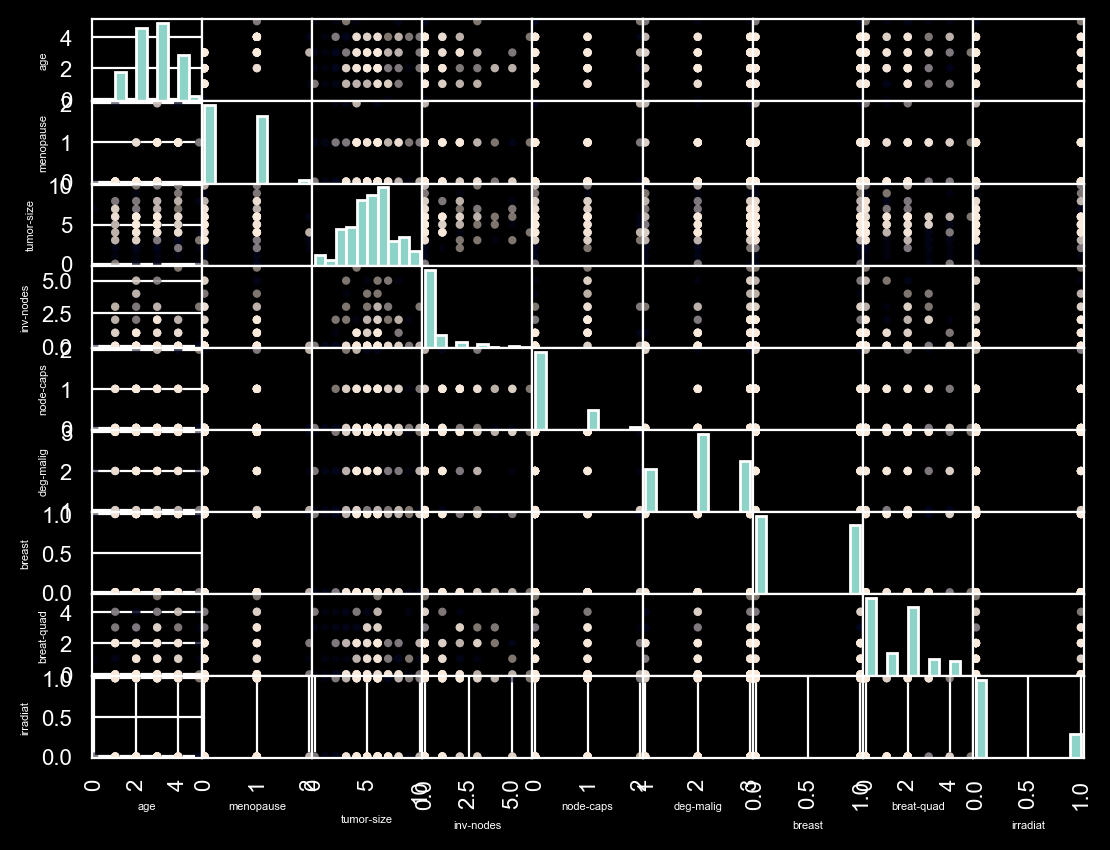

In [114]:
#plt.figure(figsize=(15,15))
plt.rcParams['figure.dpi'] = 200
plt.rcParams.update({'font.size': 4})
ax = pd.plotting.scatter_matrix(data, c=labels)
# Create a ScalarMappable for the colorbar with the same colormap
sm = ScalarMappable(cmap=plt.cm.viridis, norm=Normalize(vmin=min(labels), vmax=max(labels)))
sm.set_array([])
# Add a colorbar to the figure
#cbar = plt.colorbar(sm)
#cbar.set_label('Class Label')
plt.show()

<Axes: >

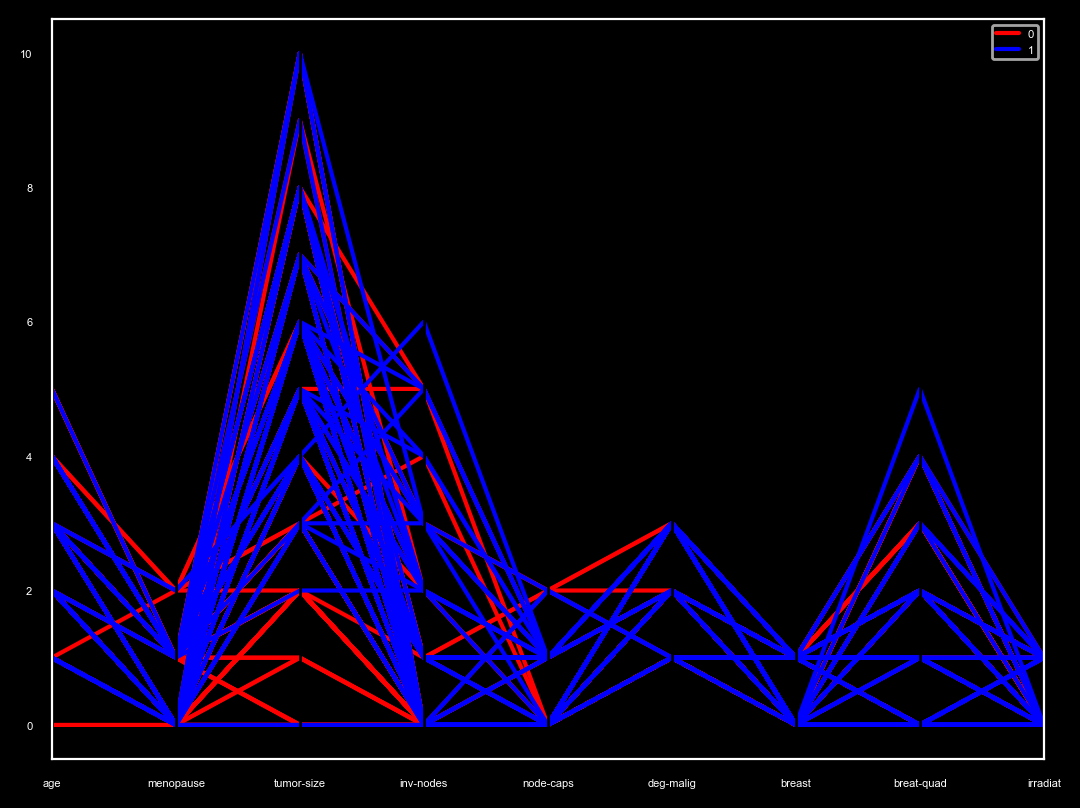

In [106]:
data_and_labels = pd.concat((data, pd.Series(labels, name="class")), axis=1) # recreate dataframe with labels
pd.plotting.parallel_coordinates(data_and_labels, "class", color=("r", "b"))

Ci-dessous nous pouvons trouver un exemple dans lequel on peut faire une classification en 3 groupes distincts à partir des nuages de points (jeu de données Iris).

In [108]:
import plotly.express as px

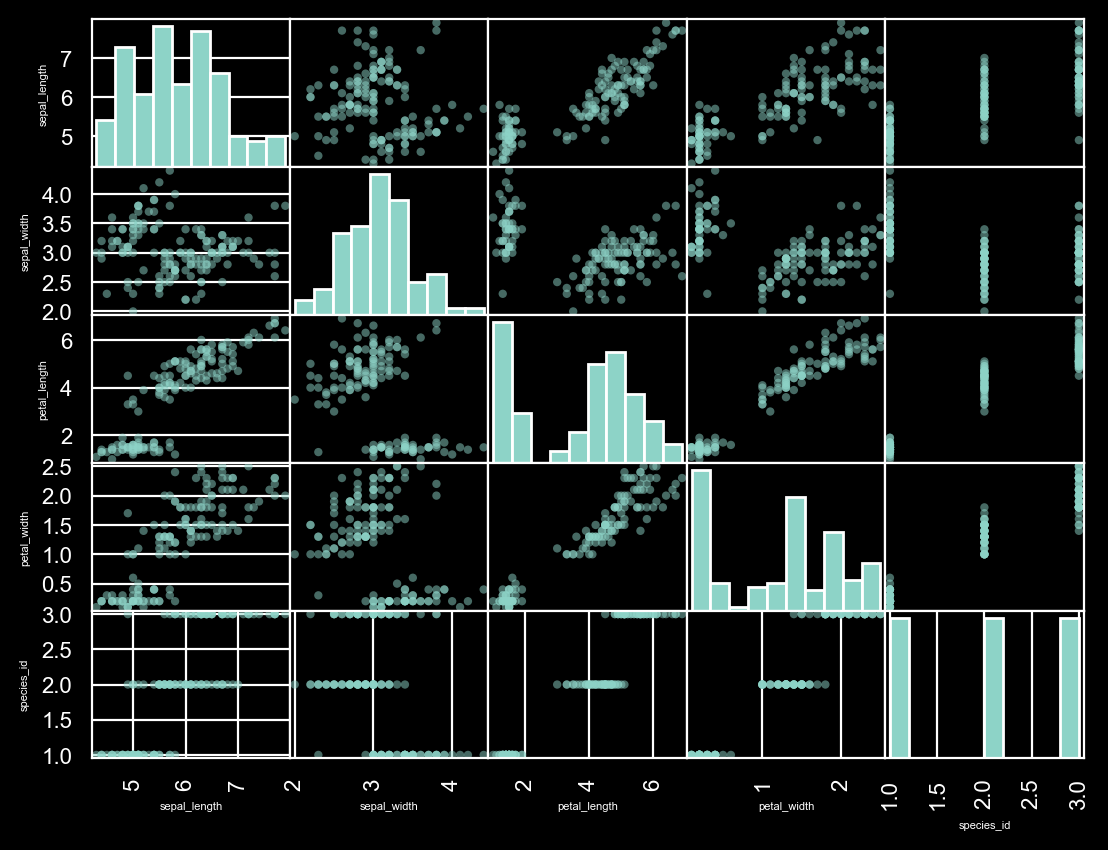

In [109]:
iris = px.data.iris()
fig = pd.plotting.scatter_matrix(iris)
plt.show()

## Partie 3. Séparation de données d'évaluation

Par la suite, nous allons appliquer des méthodes d'apprentissage sur notre jeu de données, et nous voulons pouvoir l'appliquer à  des nouvelles données. Pour évaluer si votre modèle de classification donne des prédictions correctes pour des exemples qu'il n'a jamais vu, nous allons mettre de coté une partie de nos données que nous n'utilisons pas pour construire le modèle. 

#### Question 3. Séparer votre DataFrame en deux parties aléatoires : une pour construire le modèle ("train"), 80%, et l'autre pour l'évaluer ("test"), 20%. Séparer également les étiquettes correspondantes. Vous pouvez utiliser la fonction [`sklearn.model_selection.train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

In [115]:
# import train_test_split
from sklearn.model_selection import train_test_split

In [116]:
# créer un split
train, test, train_labels, test_labels = train_test_split(data, labels, stratify=labels, random_state=1, train_size=0.8)

In [117]:
import numpy as np

In [118]:
# version "manuelle"
datasize = len(data.index) # taille du dataset
ind = np.arange(datasize) # indices jusqu'à la taille du dataset
np.random.shuffle(ind) # mélanger les indice d'une manière aléatoire
lastind = int(datasize*0.8) # prendre l'indice de l'élément qui correspond à 80% 
train = data.loc[ind[:lastind],:] # données d'apprentissage
test = data.loc[ind[(lastind+1):],:] # données de test
train_labels = labels[ind[:lastind]]
test_labels = labels[ind[(lastind+1):]]

## Partie 4. Arbre de décision

Nous allons construire notre premier modèle : un **arbre de décision** en utilisant la classe "DecisionTreeClassifier" de scikit-learn. 

<div class="alert alert-block alert-info">
    Les <b>arbres de décision</b> sont des outils non-paramétriques utilisés dans l'<i>apprentissage supervisé</i> dans le contexte de la classification et de la régression. Dans l'apprentissage supervisé, nous observons de multiples variables discriminantes et une ou plusieurs variables <i>cibles</i>. Le but est alors de créer un modèle qui prédise les valeurs des variables cibles grâce à des règle de décision simple d'apprentissage déduites des données.<br/><br/>
    Les arbres de décisions décrivent donc comment répartir une population en groupes séparés distincts, mais homogènes slon un ensemble de variabales discriminantes en fonction des objectifs fixés.
</div>

In [120]:
# import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

#### Question 4. Créer une instance de la classe [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) et construire le modèle avec la méthode [`fit`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.fit) et le jeu de données d'apprentissage. 

In [185]:
des = DecisionTreeClassifier(random_state=1) # création du modèle
tree = des.fit(train, train_labels) # apprentissage du modèle

#### Question 5. Affichez l'arbre avec la fonction [`sklearn.tree.plot_tree()`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html), et familiarisez-vous avec le modèle général et sa construction.

In [186]:
# import plot_tree
from sklearn.tree import plot_tree

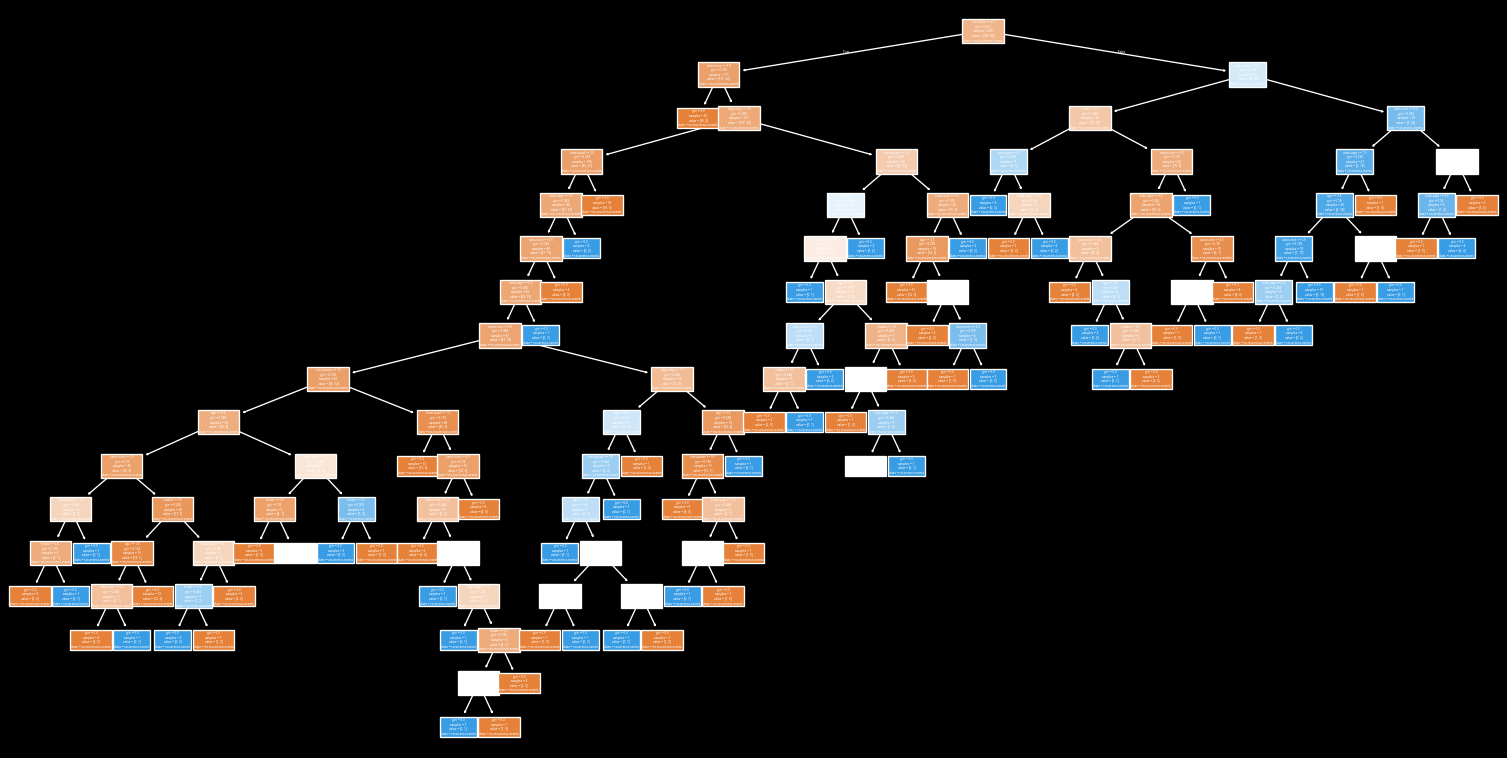

In [187]:
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=list(data.columns), class_names=['no-recurrence-events', 'recurrence-events'], filled=True, impurity=True)
plt.savefig('img/decision_tree.png', dpi=300) 
plt.show()

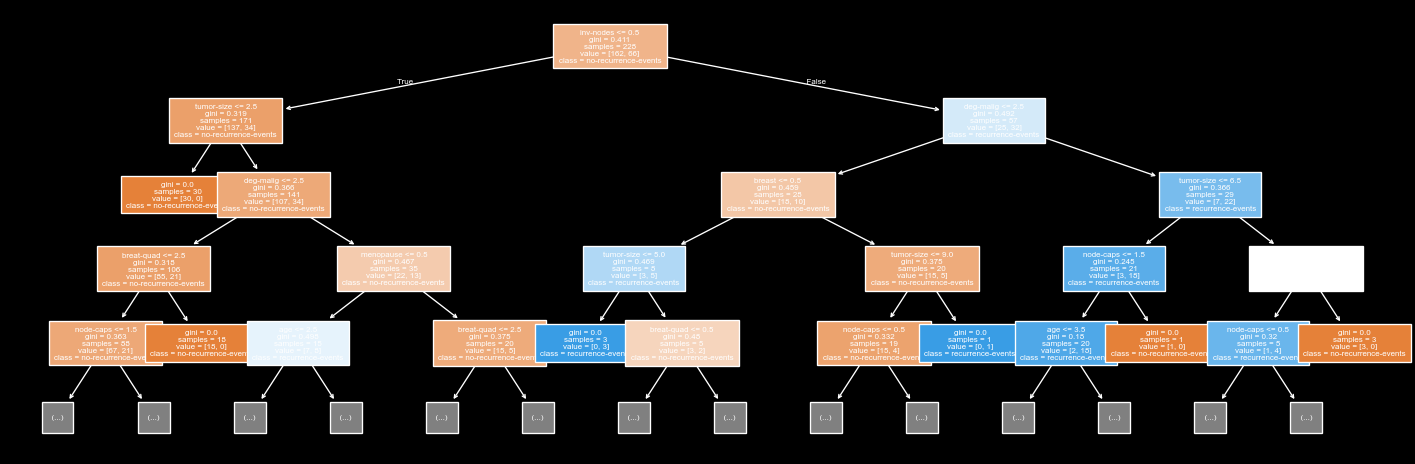

In [188]:
plt.figure(figsize=(15, 5))
plot_tree(tree, feature_names=list(data.columns), 
          class_names=['no-recurrence-events', 'recurrence-events'], 
          filled=True, impurity=True,
          max_depth=4, fontsize=6
         )
plt.tight_layout()
plt.show()

#### Question 6. Faire une prédiction avec ce modèle pour tout le jeu de test ([`predict()`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.predict)).

In [189]:
tree.predict(test)

array([1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1])

Nous allons évaluer la performance de notre modèle sur le jeu de test. Pour cela nous allons calculer la matrice de confusion à  l'aide de la fonction [`confusion_matrix(labels, predicted_labels)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html). 

In [190]:
# import confusion_matrix & ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

plt.rcParams['figure.dpi'] = 96
plt.rcParams.update({'font.size': 12})

#### Question 7.  Interpréter cette matrice et la normaliser en pourcentage/proportion. Quelle est le pourcentage de bonne prédiction (accuracy) ? Vous pouvez utiliser ensuite la classe [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) pour faire un affichage graphique.

[[26 12]
 [10  9]]


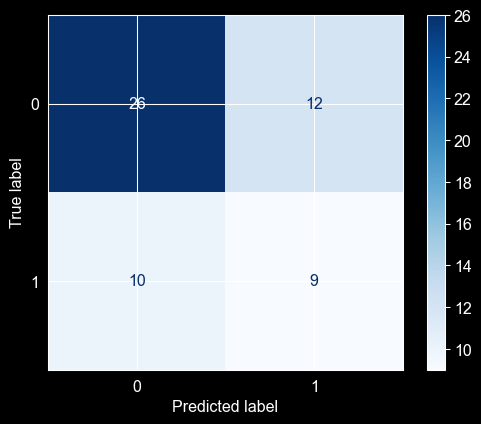

In [191]:
matrice = confusion_matrix(test_labels, tree.predict(test))
print(matrice)
disp = ConfusionMatrixDisplay(confusion_matrix=matrice, display_labels=tree.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

## Partie 6. Optimisation d'hyper-paramètres

À faire si le temps le permet.

<div class="alert alert-block alert-info">
    Un <b>hyper-paramètre</b> d'un modèle est un paramètre qui règle, par exemple, son fonctionnement, son architecture ou l'algorithme de construction (une sorte de "méta-paramètre"), contrairement aux paramètres du modèle même qui sont optimisés lors de l'apprentissage.
</div>

#### Question 8. Faire varier différents hyper-paramètres comme la pronfondeur maximale de l'arbre, le critère de qualité du "split", le nombre minimal d'exemple dans les feuille ou pour faire un "split" etc. Puis évaluer la performance.

Voici la documentation de la classe [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) :
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

## Partie 7. k-NN : k-Nearest Neighbours (classification au k plus proches voisins)

<div class="alert alert-block alert-info">
    La <b>méthode k-NN</b> est la plus intuitive des algorithmes de classification. Pour classer un nouvel exemples, elle va chercher les k exemples les plus proches dans le jeu d'apprentissage et affecter l'étiquette majoritaire parmi ces exemples.
</div>

#### Question 9. Familiarisez-vous avec l'algorithme k-NN et implémenter-le avec la classe [`KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) de `sklearn`.
#### Évaluer sa précision de classification sur le jeu de test (comme pour l'arbre de décision).

Documentation :

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [192]:
# import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

In [214]:
knn = KNeighborsClassifier(n_neighbors=5) # création du modèle
knn.fit(train, train_labels) # apprentissage du modèle

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


[[31  7]
 [13  6]]


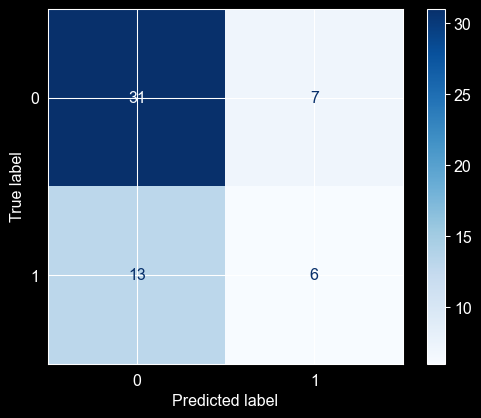

In [215]:
matrice = confusion_matrix(test_labels, knn.predict(test))
print(matrice)
disp = ConfusionMatrixDisplay(confusion_matrix=matrice, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

## Partie 8. Réseaux de neurones (Multi-Layer Perceptron)

Nous allons étudier un dernier modèle qui est un "**Perceptron Multi-Couches**" (ou *Multi-Layer Perceptron*), un **réseaux de neurones** à  plusieurs couches. 

#### Question 10. Construire un modèle [`MLPclassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) avec notre jeu d'apprentissage, et faire varier les hyper-paramètres, par exemple, la taille et le nombre de couches. Évaluer la performance du modèle. Qu'observez-vous lorsque vous augmentez la taille et la complexité du modèle ? Pourquoi ?

In [199]:
# import MLPClassifier
from sklearn.neural_network import MLPClassifier

In [218]:
model = MLPClassifier(random_state=1, max_iter=10000, hidden_layer_sizes=(4, 4), activation='logistic', solver='lbfgs')
model.fit(train, train_labels)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(4, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",10000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


[[29  9]
 [11  8]]


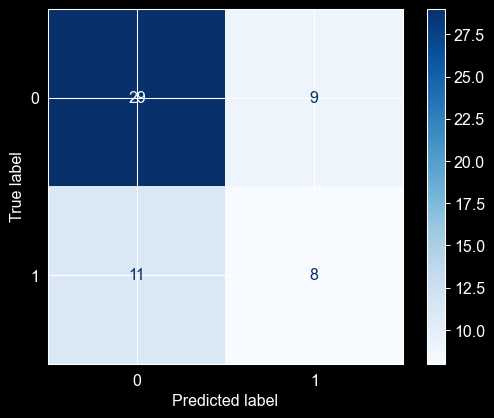

In [219]:
confusion = confusion_matrix(test_labels, model.predict(test))
print(confusion)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

## Partie Bonus.

#### Question 11. A priori, les réseaux de neurones donnent des meilleures performances avec des données normalisées en entrée. Utiliser une des classes dans le package [`sklearn.preprocessing`](https://scikit-learn.org/stable/api/sklearn.preprocessing.html#module-sklearn.preprocessing) (par exemple [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)) pour normaliser le jeu d'apprentissage et comparer le modèle obtenu avec celui sans normalisation. 

**Attention** : Le jeu de test doit être normalisé avec les mêmes paramètres que le jeu d'apprentissage.

In [194]:
# import StandardScaler
from sklearn.preprocessing import StandardScaler

In [195]:
scaler = StandardScaler()
train_ = scaler.fit_transform(train)
test_ = scaler.transform(test)

#### Question 12. Expérimenter avec d'autres représentations des attributs catégoriels, telles que le "one-hot encoding".